# Final Report: Happiness Category Classification

## Overview
This project uses the World Happiness Report 2023 dataset to classify countries into five happiness categories: Very Low, Low, Average, High, and Very High.

Several machine learning models were tested, including Random Forest, Gradient Boosting, and a basic neural network. Among all tested models, the tuned Random Forest model performed best.

## Goal
The goal of this project is to build a multi-class classification model, compare model performance, and use SHAP to better understand feature importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## Data Loading and Target Construction

The dataset used in this project is `WHR_2023.csv`. The original `happiness_score` variable was converted into five categories using `pd.qcut`, which made the task a multi-class classification problem.

In [2]:
# Load dataset
whr_df = pd.read_csv("WHR_2023.csv")

# Create 5-class target variable
whr_df['happiness_category'] = pd.qcut(
    whr_df['happiness_score'],
    q=5,
    labels=['Very Low', 'Low', 'Average', 'High', 'Very High']
)

# Define features and target
X = whr_df.drop(columns=['happiness_score', 'happiness_category'])
y = whr_df['happiness_category']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Convert labels to numeric if needed later
y_train_labels = y_train.astype('category').cat.codes
y_test_labels = y_test.astype('category').cat.codes

whr_df.head()

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,happiness_category
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535,Very High
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525,Very High
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187,Very High
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158,Very High
4,Netherlands,Western Europe,7.403,1.942,1.488,0.545,0.672,0.251,0.394,Very High


## Data Preprocessing

Numerical features were imputed using the median and scaled with `StandardScaler`. Categorical features were imputed using the most frequent value and encoded with `OneHotEncoder`. A `ColumnTransformer` was used to combine these preprocessing steps.

In [3]:
# Numeric features
numeric_features_df = X_train.select_dtypes(include=['int64', 'float64'])
numeric_features = numeric_features_df.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical features
categorical_features = ['region', 'sub-region']
categorical_features = [col for col in categorical_features if col in X_train.columns]

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocess = preprocessor.fit(X_train)

# Apply preprocessing
def apply_preprocessing(df):
    return preprocess.transform(df)

X_train_final = apply_preprocessing(X_train)
X_test_final = apply_preprocessing(X_test)

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)

X_train_final shape: (95, 16)
X_test_final shape: (42, 16)


## Best-Performing Model: Tuned Random Forest

Several models were tested in the full project workflow. The tuned Random Forest model achieved the best performance, with an accuracy of **0.5714** on the test set.

In [4]:
model_2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model_2.fit(X_train_final, y_train)

prediction_labels = model_2.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, prediction_labels))
print(classification_report(y_test, prediction_labels))

Accuracy: 0.5952380952380952
              precision    recall  f1-score   support

     Average       0.55      0.75      0.63         8
        High       0.50      0.50      0.50         8
         Low       0.50      0.50      0.50         8
   Very High       0.86      0.67      0.75         9
    Very Low       0.62      0.56      0.59         9

    accuracy                           0.60        42
   macro avg       0.61      0.59      0.59        42
weighted avg       0.61      0.60      0.60        42



## Model Comparison Summary

The tuned Random Forest model performed best among all tested models.

### Accuracy Comparison
- Baseline Random Forest: **0.4762**
- Tuned Random Forest: **0.5714**
- GridSearchCV Random Forest: **0.5000**
- Gradient Boosting: **0.4524**
- Neural Network: **0.4762**

This suggests that the manually tuned Random Forest model provided the best balance of performance and stability for this dataset.

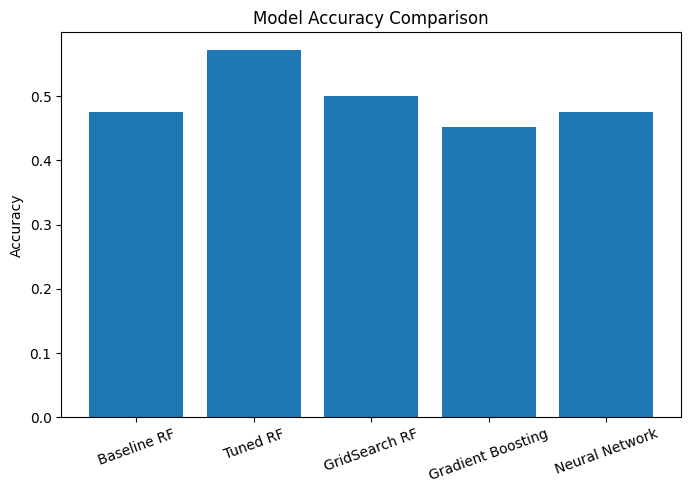

In [5]:
model_names = [
    "Baseline RF",
    "Tuned RF",
    "GridSearch RF",
    "Gradient Boosting",
    "Neural Network"
]

accuracies = [0.4762, 0.5714, 0.5000, 0.4524, 0.4762]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

## Confusion Matrix

The confusion matrix below shows how well the tuned Random Forest model predicted each happiness category.

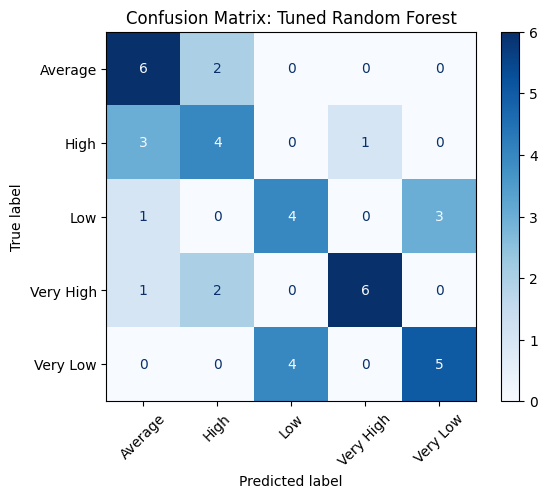

In [6]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediction_labels,
    xticks_rotation=45,
    cmap="Blues"
)
plt.title("Confusion Matrix: Tuned Random Forest")
plt.show()

## Model Explainability with SHAP

To better understand the tuned Random Forest model, SHAP was used to analyze feature importance. SHAP helps explain which transformed features contribute most strongly to predictions.

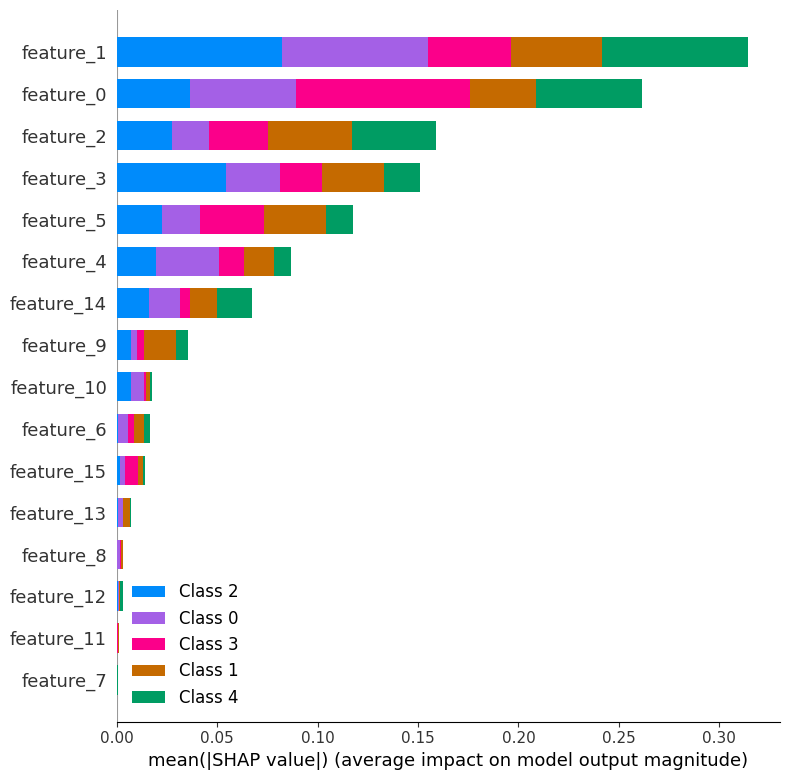

In [7]:
import shap

explainer = shap.Explainer(model_2, X_test_final)
shap_values = explainer(X_test_final)

feature_names = [f"feature_{i}" for i in range(X_test_final.shape[1])]
X_test_df = pd.DataFrame(X_test_final, columns=feature_names)

shap.summary_plot(shap_values, X_test_df)

## SHAP Interpretation

The SHAP summary plot shows that some transformed features have much stronger effects on model output than others. This improves interpretability compared with using accuracy scores alone.

At the same time, interpretation is somewhat limited because the feature names are generic after preprocessing. Even so, SHAP provides a more transparent view of how the model makes decisions and helps justify the predictions.

## Conclusion

This project applied machine learning methods to classify countries into five happiness categories using the World Happiness Report 2023 dataset.

Among all tested models, the tuned Random Forest classifier performed best, with an accuracy of **0.5714**. This model outperformed the baseline Random Forest, GridSearchCV model, Gradient Boosting model, and neural network.

Overall, this project demonstrates a complete machine learning workflow: target construction, preprocessing, model training, evaluation, comparison, and explainability using SHAP.